# Outliers test (Liu_like_v01) 



In [ ]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mi_path = PROJECT_ROOT / "src" / "calibration" / "model_inference.py"
spec = importlib.util.spec_from_file_location("model_inference_local", mi_path)
mi = importlib.util.module_from_spec(spec)
assert spec is not None and spec.loader is not None
spec.loader.exec_module(mi)

FEATURE_ORDER = mi.FEATURE_ORDER
load_model_from_run = mi.load_model_from_run
predict_iv = mi.predict_iv

plt.style.use("seaborn-v0_8-whitegrid")

In [53]:
MODEL_DIR = "Liu_like_v01"
CHECKPOINT_NAME = "model_best.pt"
SPLIT = "test"

ABS_ERROR_THRESHOLD = 0.05
OUTLIER_QUANTILE = 0.999
MIN_HARD_OUTLIERS = 10
RANDOM_SEED = 42

In [54]:
def _load_yaml_dict(path: Path) -> dict:
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f) or {}
    return data if isinstance(data, dict) else {}


def _resolve_data_dir(run_dir: Path) -> Path:
    run_cfg = _load_yaml_dict(run_dir / "model_training_copy.yaml")
    cfg_data_dir = run_cfg.get("data", {}).get("dir")
    if cfg_data_dir:
        return PROJECT_ROOT / cfg_data_dir

    default_cfg = _load_yaml_dict(PROJECT_ROOT / "configs" / "model_training.yaml")
    default_data_dir = default_cfg.get("data", {}).get("dir")
    if default_data_dir:
        return PROJECT_ROOT / default_data_dir

    raise FileNotFoundError("No se pudo resolver data_dir")


def _target_col(df: pd.DataFrame) -> str:
    return "IV" if "IV" in df.columns else str(df.columns[-1])

In [ ]:
# load modelo + test, hacer forward y marcar outliers
model, model_device, run_dir, model_cfg, norm_stats = load_model_from_run(
    project_root=PROJECT_ROOT,
    model_dir=MODEL_DIR,
    checkpoint_name=CHECKPOINT_NAME,
    device="auto",
)

data_dir = _resolve_data_dir(run_dir)
df_test = pd.read_parquet(data_dir / f"{SPLIT}.parquet").copy()

target_col = _target_col(df_test)
feature_cols = list(FEATURE_ORDER)
if not all(c in df_test.columns for c in feature_cols):
    feature_cols = [c for c in df_test.columns if c != target_col]

x = df_test.loc[:, feature_cols].to_numpy(dtype=np.float64)
y_true = df_test[target_col].to_numpy(dtype=np.float64).reshape(-1)
y_pred = predict_iv(
    model=model,
    features=x,
    device=model_device,
    batch_size=8192,
    normalization_stats=norm_stats,
)

abs_error = np.abs(y_pred - y_true)
q_thr = float(np.quantile(abs_error, OUTLIER_QUANTILE))
outlier_hard = abs_error > ABS_ERROR_THRESHOLD
outlier_q = abs_error >= q_thr

if int(outlier_hard.sum()) >= MIN_HARD_OUTLIERS:
    outlier_mask = outlier_hard
else:
    outlier_mask = outlier_q

df_eval = df_test.copy()
df_eval["is_outlier"] = outlier_mask

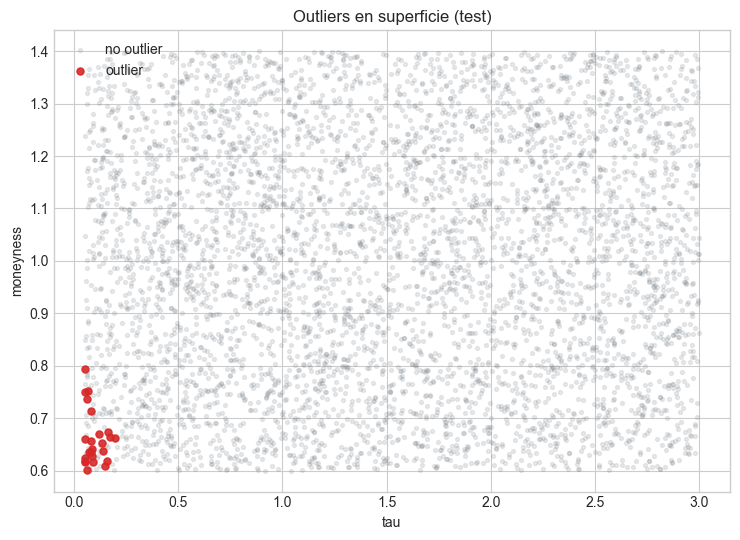

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

non_out = df_eval.loc[~df_eval["is_outlier"], ["tau", "moneyness"]]
if len(non_out) > 5000:
    non_out = non_out.sample(5000, random_state=RANDOM_SEED)

ax.scatter(non_out["tau"], non_out["moneyness"], s=8, alpha=0.15, color="#6c757d", label="no outlier")
ax.scatter(
    df_eval.loc[df_eval["is_outlier"], "tau"],
    df_eval.loc[df_eval["is_outlier"], "moneyness"],
    s=26,
    alpha=0.9,
    color="#d62828",
    label="outlier",
)
ax.set_title("Outliers en superficie (test)")
ax.set_xlabel("tau")
ax.set_ylabel("moneyness")
ax.legend(loc="best")

plt.tight_layout()
plt.show()